In [1]:
# =========================
# Complex-paired barycentric over [-1,1]
# =========================
import jax, jax.numpy as jnp
from flax import nnx
from jax import lax
import optax
from tqdm import tqdm
from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle

jax.config.update("jax_enable_x64", True)
DTYPE  = jnp.float64
CDTYPE = jnp.complex128

In [2]:
# --------- helpers
def softplus_with_floor(x, floor=1e-3):
    return floor + jax.nn.softplus(x)

def complex_from_mag_phase(log_mag, phase):
    # returns e^{log_mag} * e^{i*phase}
    mag = jnp.exp(log_mag)
    return mag * (jnp.cos(phase) + 1j * jnp.sin(phase))

In [3]:
class ConjugatePairNodes(nnx.Module):
    """
    n_pairs complex nodes in upper half-plane:
        z_j = (raw_xi_j) + i * softplus(raw_eta_j) + i*eta_floor
    No restriction on Re z_j. 
    """
    raw_xi: nnx.Param    # (n_pairs,)  -- now UNCONSTRAINED real parts
    raw_eta: nnx.Param   # (n_pairs,)
    eta_floor: float

    def __init__(self, n_pairs: int, *, eta_floor: float = 1e-3, rngs: nnx.Rngs = nnx.Rngs(0), jax_rngs = jax.random.key(0)):
        self.raw_xi  = nnx.Param(jax.random.normal(jax_rngs, shape = (n_pairs,), dtype=DTYPE))
        self.raw_eta = nnx.Param(jax.random.normal(jax_rngs, shape = (n_pairs,), dtype=DTYPE))
        self.eta_floor = eta_floor

    def nodes_upper(self) -> jnp.ndarray:
        xi  = self.raw_xi.value                     # free on R
        eta = softplus_with_floor(self.raw_eta.value, self.eta_floor)
        return (xi + 1j * eta).astype(CDTYPE)

    def nodes_full(self) -> jnp.ndarray:
        zu = self.nodes_upper()
        return jnp.concatenate([zu, jnp.conj(zu)], axis=0)

In [4]:
class ConjugatePairWeights(nnx.Module):
    """
    Complex barycentric weights with conjugate pairing.
      w_upper = exp(log_mag) * exp(i*phase)
      w_full  = concat(w_upper, conj(w_upper))
    """
    log_mag: nnx.Param    # (n_pairs,)
    phase: nnx.Param      # (n_pairs,)

    def __init__(self, n_pairs: int, *, rngs: nnx.Rngs = nnx.Rngs(0)):
        self.log_mag = nnx.Param(jnp.zeros((n_pairs,), dtype=DTYPE))
        self.phase   = nnx.Param(jnp.zeros((n_pairs,), dtype=DTYPE))

    def weights_upper(self) -> jnp.ndarray:
        return complex_from_mag_phase(self.log_mag.value, self.phase.value).astype(CDTYPE)

    def weights_full(self) -> jnp.ndarray:
        wu = self.weights_upper()
        return jnp.concatenate([wu, jnp.conj(wu)], axis=0)        # (2*n_pairs,)

In [5]:
class ConjugatePairValues(nnx.Module):
    """
    Complex nodal values with conjugate pairing. Supports D output dims.
      V_upper = V_re + i V_im
      V_full  = concat(V_upper, conj(V_upper))
    If you DO know an analytic continuation f(z), you can pass V_init_upper = f(z_upper)
    (complex) to initialize exactly; otherwise we train these.
    """
    V_re: nnx.Param       # (n_pairs, D)
    V_im: nnx.Param       # (n_pairs, D)
    D: int

    def __init__(self, n_pairs: int, D: int = 1, V_init_upper: jnp.ndarray | None = None,
                 rngs: nnx.Rngs = nnx.Rngs(0)):
        self.D = D
        if V_init_upper is None:
            self.V_re = nnx.Param(jnp.zeros((n_pairs, D), dtype=DTYPE))
            self.V_im = nnx.Param(jnp.zeros((n_pairs, D), dtype=DTYPE))
        else:
            V_init_upper = jnp.asarray(V_init_upper).astype(CDTYPE)  # (n_pairs, D)
            self.V_re = nnx.Param(jnp.real(V_init_upper).astype(DTYPE))
            self.V_im = nnx.Param(jnp.imag(V_init_upper).astype(DTYPE))

    def values_upper(self) -> jnp.ndarray:
        return (self.V_re.value + 1j * self.V_im.value).astype(CDTYPE)

    def values_full(self) -> jnp.ndarray:
        Vu = self.values_upper()                                   # (n_pairs, D)
        return jnp.concatenate([Vu, jnp.conj(Vu)], axis=0)         # (2*n_pairs, D)



In [6]:
# --------- complex barycentric lambdas (no exact-hit branch needed if Im z_j > 0)
def barycentric_lambdas_complex(x: jnp.ndarray, nodes: jnp.ndarray, w: jnp.ndarray):
    """
    x: (B,) real; nodes: (M,) complex; w: (M,) complex.
    Returns λ(x) in C^{B×M} with rows summing to 1.
    """
    x = x.ravel().astype(DTYPE)
    nodes = nodes.astype(CDTYPE)
    w = w.astype(CDTYPE)
    diff = x[:, None].astype(CDTYPE) - nodes[None, :]            # (B,M) complex; never 0 if Im nodes != 0
    z = w[None, :] / diff                                       # (B,M)
    S = jnp.sum(z, axis=1, keepdims=True)                       # (B,1)
    lam = z / S                                                 # (B,M)
    return lam

# --------- the layer
class ComplexBarycentricAttention(nnx.Module):
    """
    Barycentric rational layer with complex conjugate-paired nodes/weights/values.
    For real x, output is (nearly) real if pairing is kept.
    """
    nodes_param: ConjugatePairNodes
    weights_param: ConjugatePairWeights
    values_param: ConjugatePairValues
    return_real: bool
    eta_floor: float

    def __init__(self, n_pairs: int, D: int = 1, *,
                 eta_floor: float = 1e-3,
                 xi_scale: float = 1.0,
                 V_init_upper: jnp.ndarray | None = None,
                 return_real: bool = True,
                 rngs: nnx.Rngs = nnx.Rngs(0)):
        self.nodes_param   = ConjugatePairNodes(n_pairs, eta_floor=eta_floor, rngs=rngs)
        self.weights_param = ConjugatePairWeights(n_pairs, rngs=rngs)
        self.values_param  = ConjugatePairValues(n_pairs, D=D, V_init_upper=V_init_upper, rngs=rngs)
        self.return_real = return_real
        self.eta_floor = eta_floor

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = x.ravel().astype(DTYPE)                                      # (B,)
        z_full = self.nodes_param.nodes_full()                           # (M=2n,)
        w_full = self.weights_param.weights_full()                        # (M,)
        V_full = self.values_param.values_full()                          # (M,D)
        lam = barycentric_lambdas_complex(x, z_full, w_full)              # (B,M)
        y = lam @ V_full                                                  # (B,D) complex
        return jnp.real(y) if self.return_real else y

    # (optional) small regularizer helpers you can add to your loss:
    def reg_keep_off_axis(self, margin=1e-3):
        """Penalize imag parts getting too small: sum relu(margin - eta)."""
        eta = softplus_with_floor(self.nodes_param.raw_eta.value, self.eta_floor)
        return jnp.sum(jax.nn.relu(margin - eta))

    def reg_node_spread(self, min_sep=1e-2):
        """Discourage clustering along Re axis in upper half; rough quadratic barrier."""
        xi = jnp.tanh(self.nodes_param.raw_xi.value)
        diffs = xi[None, :] - xi[:, None]
        mask = 1.0 - jnp.eye(xi.shape[0], dtype=DTYPE)
        sepsq = (diffs**2 + 1e-12) * mask
        return jnp.sum(jax.nn.relu(min_sep**2 - sepsq))



In [ ]:
# ---------- usage example (fits sin(2πkx) on [-1,1] by training nodes/weights/values)
# target
k = 1
f = lambda x: jnp.sin(2.0 * jnp.pi * k * x)

# data
B_tr, B_ev = 2048, 10000
x_tr = jnp.linspace(-1.0, 1.0, B_tr, dtype=DTYPE)
y_tr = f(x_tr)[:, None]                                # (B_tr,1)
x_ev = jnp.linspace(-1.0, 1.0, B_ev, dtype=DTYPE)
y_ev = f(x_ev)[:, None]

# model
n_pairs = 128
model = ComplexBarycentricAttention(n_pairs=n_pairs, D=1, eta_floor=1e-3, rngs=nnx.Rngs(0))

init_graphdef, init_state = nnx.split(model)
init_model = nnx.merge(init_graphdef, init_state)


# optimizer
lr = 1e-3
opt = nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)

def loss_fn(m, x, y):
    pred = m(x)                                          # (B,1) real
    data = jnp.mean((pred - y)**2)
    # very light regularization to keep poles off the axis and distributed:
    reg = 1e-4 * m.reg_keep_off_axis(5e-4) + 1e-6 * m.reg_node_spread(1e-2)
    return data

@nnx.jit
def step(m, opt, x, y):
    val, grads = nnx.value_and_grad(loss_fn)(m, x, y)
    opt.update(m, grads)
    return val, grads

# train
for it in tqdm(range(50000)):
    val, grads = step(model, opt, x_tr, y_tr)
    if it % 2000 == 0:
        with jax.disable_jit():
            rel = jnp.linalg.norm(model(x_ev) - y_ev) / jnp.linalg.norm(y_ev)
            print(f"iter {it:4d} | loss {val:.3e} | rel-L2 {rel:.3e}")


  0%|          | 54/50000 [00:00<03:34, 233.27it/s]

iter    0 | loss 4.998e-01 | rel-L2 1.849e+00


  4%|▍         | 2055/50000 [00:09<03:21, 237.99it/s]

iter 2000 | loss 4.983e-01 | rel-L2 9.993e-01


  8%|▊         | 4056/50000 [00:18<03:19, 230.19it/s]

...

 16%|█▌        | 8054/50000 [00:37<03:22, 207.30it/s]

iter 8000 | loss 4.891e-01 | rel-L2 9.901e-01


 20%|██        | 10056/50000 [00:47<02:59, 222.13it/s]

iter 10000 | loss 4.757e-01 | rel-L2 9.765e-01


 21%|██        | 10253/50000 [00:48<03:16, 202.30it/s]

In [14]:
model.nodes_param.nodes_full()

Array([-1.82786695e-01+0.58666143j, -7.69852439e-01+0.3837485j ,
        1.79399574e+00+1.94842568j,  2.11323059e-01+0.78017956j,
        1.04215896e-01+0.723723j  , -3.49420317e-01+0.51753099j,
        1.16857195e+00+1.43944372j,  3.62459606e-01+0.86459584j,
        1.08177937e-01+0.72576071j, -8.95242696e-01+0.35675588j,
        1.03326927e+00+1.33767985j, -1.58139091e+00+0.19564667j,
        3.91463463e-01+0.88141039j,  2.49412028e+00+2.57418614j,
        2.82169450e-01+0.81906962j, -2.60789082e-01+0.55311945j,
       -5.12126204e-01+0.47117535j,  3.91873231e-01+0.88164932j,
       -1.72894965e-01+0.59103349j,  1.48213325e+00+1.68731089j,
        8.23752738e-02+0.71256058j,  1.64997466e-01+0.75541293j,
        2.11995701e-01+0.78054305j,  7.00436935e-02+0.70631078j,
       -1.43534316e+00+0.22304956j, -1.71892789e-01+0.59147788j,
        1.09160203e+00+1.38114982j, -2.24908538e+00+0.10560979j,
       -5.41009447e-01+0.46036877j,  3.25067278e-01+0.84320462j,
       -1.17473845e+00+0.

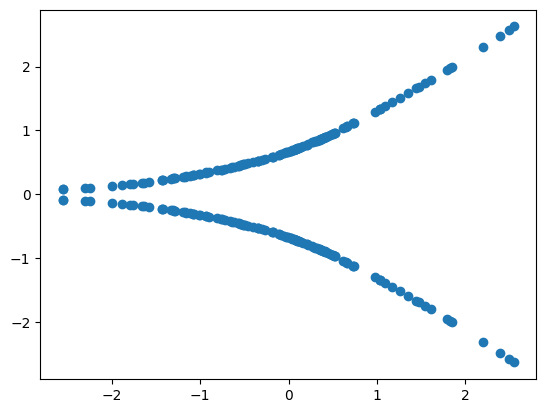

In [9]:
import matplotlib.pyplot as plt
plt.scatter(jnp.real(model.nodes_param.nodes_full()), jnp.imag(model.nodes_param.nodes_full()))

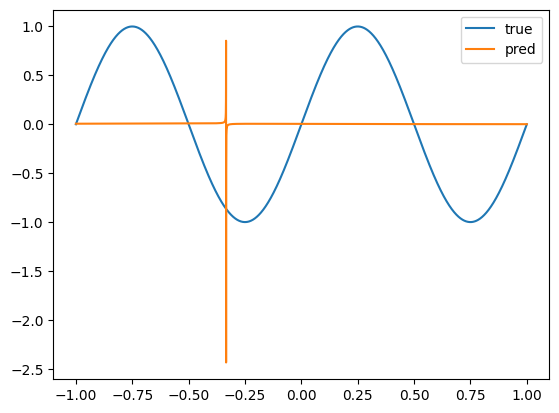

In [10]:
import matplotlib.pyplot as plt
plt.plot(x_ev, y_ev, label="true")
plt.plot(x_ev, model(x_ev), label="pred")
plt.legend()